In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Chec-seq promoter-level signal files for finding reproducible samples
sumprom_chec_glob = "sumproms/*.gz"

# Motif binding scores (see analysis code for calculation)
binding_score_base_dir = "binding_score_at_motifs"
background_binding_dir = f"{binding_score_base_dir}/background_binding_arrays"

# File matching patterns
representative_regex_search = ["__*loc-prom__*family*__fl25__*.csv"]
background_array_pattern = "__*__loc-prom__signal_bg__fl25*.npy"

# Reproducibility filtering threshold
corr_cutoff = 0.895

## Imports

In [3]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Helper Functions

In [4]:
# Load a sample table and its matched background array
def load_sample(sample_name, regex_search):
    if len(regex_search) == 1:
        df_files = glob.glob(
            f"{binding_score_base_dir}/{sample_name}/{sample_name}{regex_search[0]}"
        )
    if len(regex_search) == 2:
        df_files = glob.glob(
            f"{binding_score_base_dir}/{sample_name}/{sample_name}{regex_search[0]}"
        ) + glob.glob(
            f"{binding_score_base_dir}/{sample_name}/{sample_name}{regex_search[1]}"
        )
    if len(df_files) != 1:
        return None, None
    bg_files = glob.glob(
        f"{background_binding_dir}/{sample_name}{background_array_pattern}"
    )
    if len(bg_files) != 1:
        return None, None
    df = pd.read_csv(df_files[0])
    z_bg = np.load(bg_files[0])[:, 1]
    return z_bg, df

# Keep only reproducible samples based on replicate correlations
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

## Data Loading

In [5]:
# Define the TF families used in the figure
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}

all_samples = set(sum(dbd_fam_dict.values(), []))

family_name = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "SOX",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

## Data Processing

In [6]:
# Load promoter summary signals from all sequencing batches
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

# Keep reproducible samples and average replicates by TF
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit("_", n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
good_samples = sumprom.columns[sumprom.columns.isin(all_samples)].tolist()

# Load the representative family-level binding tables for good samples
df_dict_representative = {}
bg_dict = {}

for sample in good_samples:
    bg_dict[sample], df_dict_representative[sample] = load_sample(
        sample,
        regex_search=representative_regex_search,
    )

# Set the family plotting order used in the original notebook
plotting_order_fam = ["FOXK1", "BATF3", "GATA1", "HEY1", "GABPA", "NFAC4", "TF2LY", "PO3F2", "HXD10", "SOX10"]

## Plotting

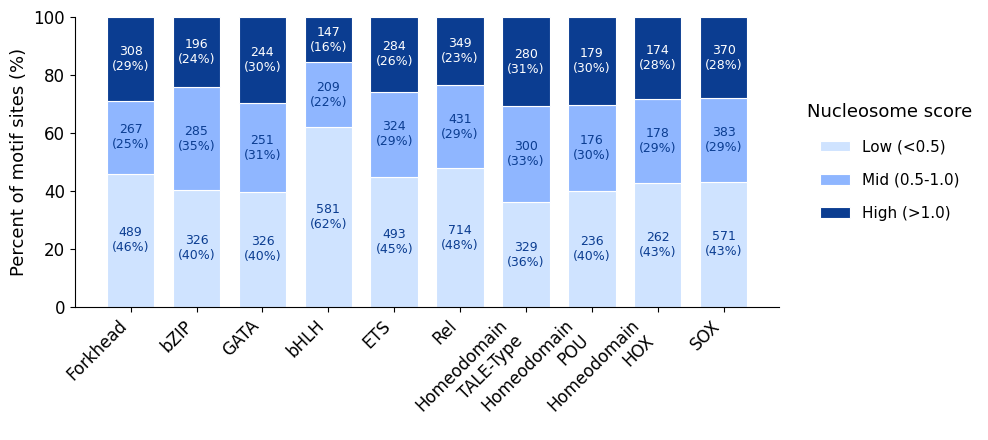

In [7]:
# Plot stacked nucleosome-score fractions by TF family
def plot_family_nucscore_stacks(df_dict_representative, dbd_fam_dict, plotting_order_fam, family_name,
                               good_samples=None, score_col="nuc_score_f7", bins=(0.5, 1.0),
                               figsize=(10, 4.5)):

    b0, b1 = bins

    # one representative per family
    fam_rep = {}
    for fam in plotting_order_fam:
        for s in dbd_fam_dict.get(fam, []):
            if (good_samples is None or s in good_samples) and s in df_dict_representative:
                fam_rep[fam] = s
                break

    # compute low/mid/high fractions per family from the representative df
    rows = []
    for fam, rep in fam_rep.items():
        s = pd.to_numeric(df_dict_representative[rep][score_col], errors="coerce").dropna()
        low, mid, high = (s < b0).sum(), ((s >= b0) & (s <= b1)).sum(), (s > b1).sum()
        N = len(s)
        rows.append(dict(fam=fam, rep=rep, N=N,
                         N_low=low, N_mid=mid, N_high=high,
                         low_=100*low/N, mid_=100*mid/N, high_=100*high/N))

    res = pd.DataFrame(rows)
    x = np.arange(len(res))

    fig, ax = plt.subplots(figsize=figsize)
    c_low, c_mid, c_high, w = "#CFE3FF", "#8FB6FF", "#0B3D91", 0.72

    ax.bar(x, res["low_"],  width=w, color=c_low,  edgecolor="white", lw=0.8, label=f"Low (<{b0})")
    ax.bar(x, res["mid_"],  width=w, bottom=res["low_"],             color=c_mid,  edgecolor="white", lw=0.8, label=f"Mid ({b0}-{b1})")
    ax.bar(x, res["high_"], width=w, bottom=res["low_"]+res["mid_"], color=c_high, edgecolor="white", lw=0.8, label=f"High (>{b1})")

    # annotate each segment (skip tiny ones)
    for i, r in res.iterrows():
        segs = [("N_low","low_", 0,                 "#0B3D91"),
                ("N_mid","mid_", r["low_"],         "#0B3D91"),
                ("N_high","high_", r["low_"]+r["mid_"], "white")]
        for n_key, p_key, btm, col in segs:
            p, n = float(r[p_key]), int(r[n_key])
            if n and p >= 6:
                ax.text(i, btm + p/2, f"{n}\n({p:.0f}%)", ha="center", va="center", fontsize=9, color=col)

    ax.set_xticks(x)
    ax.set_xticklabels([family_name.get(f, f) for f in res["fam"]], rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Percent of motif sites (%)", fontsize=13)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="y", labelsize=12)

    ax.legend(title="Nucleosome score", title_fontsize=13, fontsize=11,
              loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, labelspacing=1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
    return res


res = plot_family_nucscore_stacks(df_dict_representative, dbd_fam_dict, plotting_order_fam, family_name, good_samples=good_samples)